In [34]:
import pandas as pd
from matplotlib import pyplot as plt

# Data on the importance of religion in the lives of people in a particular country

In [2]:
importance = pd.read_csv('how-important-religion-is-in-your-life.csv')
importance.head()

,entity,code,year,very_important_in_life_religion,rather_important_in_life_religion,not_very_important_in_life_religion,notatall_important_in_life_religion,dont_know_important_in_life_religion,no_answer_important_in_life_religion,very_important_in_life_religion__annotations,rather_important_in_life_religion__annotations,not_very_important_in_life_religion__annotations,notatall_important_in_life_religion__annotations,dont_know_important_in_life_religion__annotations,no_answer_important_in_life_religion__annotations
0,Albania,ALB,1998,24.22422,34.534530,28.228230,10.71071,2.302302,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,ALB,2004,27.50000,31.200000,25.200000,14.20000,1.900000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,ALB,2010,15.71519,35.645400,27.452140,18.17237,1.967477,1.047418,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,ALB,2022,24.36961,48.684380,15.685870,10.84857,0.061695,0.349869,NaN,NaN,NaN,NaN,NaN,NaN
4,Algeria,DZA,2004,90.63963,7.488299,0.936037,NaN,0.936037,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
importance.isna().sum() / len(importance)

entity                                               0.0000
code                                                 0.0100
year                                                 0.0000
very_important_in_life_religion                      0.0000
rather_important_in_life_religion                    0.0000
not_very_important_in_life_religion                  0.0025
notatall_important_in_life_religion                  0.0175
dont_know_important_in_life_religion                 0.0125
no_answer_important_in_life_religion                 0.0000
very_important_in_life_religion__annotations         0.9900
rather_important_in_life_religion__annotations       0.9900
not_very_important_in_life_religion__annotations     0.9900
notatall_important_in_life_religion__annotations     0.9900
dont_know_important_in_life_religion__annotations    0.9900
no_answer_important_in_life_religion__annotations    0.9900
dtype: float64

**The last 6 columns contain too many nans, so we can safely delete them** 

In [13]:
importance.drop(['very_important_in_life_religion__annotations', 
                'rather_important_in_life_religion__annotations',
                'not_very_important_in_life_religion__annotations',
                'notatall_important_in_life_religion__annotations',
                'dont_know_important_in_life_religion__annotations',
                'no_answer_important_in_life_religion__annotations'],
                axis=1, 
                inplace=True)

In [14]:
importance.describe()

,year,very_important_in_life_religion,rather_important_in_life_religion,not_very_important_in_life_religion,notatall_important_in_life_religion,dont_know_important_in_life_religion,no_answer_important_in_life_religion
count,400.000000,400.000000,400.000000,399.000000,393.000000,395.000000,400.000000
mean,2008.862500,39.708636,24.618583,20.540174,13.907680,1.071966,0.461093
std,9.553101,28.743844,11.042982,13.376816,13.056979,2.220445,1.268939
min,1993.000000,1.400000,0.909580,0.005463,0.011139,0.000000,0.000000
25%,2004.000000,15.027638,16.509105,8.788017,3.060705,0.053072,0.000000
50%,2010.000000,30.519690,25.448380,21.929670,9.959350,0.330788,0.083333
75%,2014.000000,59.146822,32.066985,31.176890,22.500000,1.084608,0.528669
max,2022.000000,98.891770,56.801590,60.383380,75.800000,24.253770,17.275750


**There are no values greater than 100% or less than zero anywhere. Everything is fine.**

In [19]:
importance['total'] = (importance[['very_important_in_life_religion', 
                                 'rather_important_in_life_religion',
                                 'not_very_important_in_life_religion',
                                 'notatall_important_in_life_religion',
                                 'dont_know_important_in_life_religion',
                                 'no_answer_important_in_life_religion']]
                       .sum(axis=1))

print(importance['total'].min())
print(importance['total'].max())

99.9999856
100.000013


**The total for this line is expected to be 100%. Everything is fine.**

In [22]:
print(len(importance['entity'].unique()))
importance['entity'].unique()

117


array(['Albania', 'Algeria', 'Andorra', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bangladesh', 'Belarus',
       'Belgium', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Canada', 'Chile', 'China', 'Colombia',
       'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Dominican Republic',
       'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Ethiopia',
       'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Guatemala', 'Haiti', 'Hong Kong', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Italy', 'Japan', 'Jordan',
       'Kazakhstan', 'Kenya', 'Kosovo', 'Kuwait', 'Kyrgyzstan', 'Latvia',
       'Lebanon', 'Libya', 'Lithuania', 'Luxembourg', 'Macao', 'Malaysia',
       'Maldives', 'Mali', 'Malta', 'Mexico', 'Moldova', 'Mongolia',
       'Montenegro', 'Morocco', 'Myanmar', 'Netherlands', 'New Zealand',
       'Nicaragua', 'Nigeria', 'North Macedonia', 'Northern Cyprus',
       'Nort

**We have data on 117 countries. They are listed above**

In [38]:
entries_by_year = importance.groupby('entity').size().sort_values()
entries_by_year

entity
Burkina Faso          1
Bolivia               1
Dominican Republic    1
El Salvador           1
Maldives              1
                     ..
South Korea           6
Turkey                6
Spain                 6
Sweden                6
United States         6
Length: 117, dtype: int64

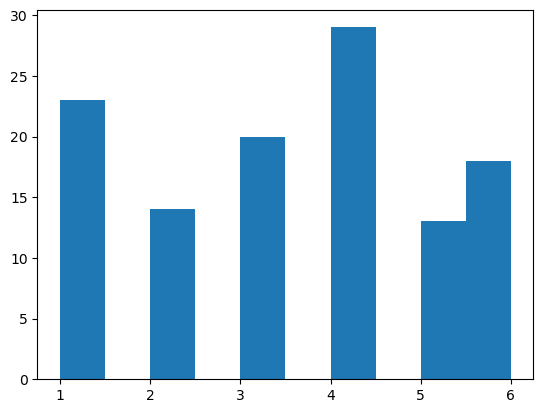

In [36]:
plt.hist(x)
plt.show()

**We have an unbalanced number of entries by year for each country. The minimum number is 1, and the maximum is 6.**